In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
import json
import os

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED     = 42
N_TRIALS = 150   
N_FOLDS  = 5     

np.random.seed(SEED)
print('Imported')
print(f'Optuna: {optuna.__version__}')

Imported
Optuna: 4.8.0


In [2]:
X_train = pd.read_csv('data/processed/X_train.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def rmsle_cv(model, X=X_train, y=y_train):
    scores = cross_val_score(
        model, X, y,
        scoring='neg_mean_squared_error',
        cv=kf, n_jobs=-1
    )
    return np.sqrt(-scores).mean()

print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'Folds: {N_FOLDS},  Trials per model: {N_TRIALS}')

X_train: (1458, 94)
y_train: (1458,)
Folds: 5,  Trials per model: 150


In [3]:
def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 500, 3000, step=100),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_jobs':           -1,
        'random_state':     SEED,
        'verbosity':        0,
    }
    model = xgb.XGBRegressor(**params)
    return rmsle_cv(model)

study_xgb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_warmup_steps=10),
    study_name='xgb_tuning'
)

print(f'Optimiztio XGBoost ({N_TRIALS} trials)...')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

best_xgb = study_xgb.best_params
print(f'\nBest params XGBoost:')
for k, v in best_xgb.items():
    print(f'   {k:22s} = {v}')
print(f'   RMSLE = {study_xgb.best_value:.5f}')

Optimiztio XGBoost (150 trials)...


  0%|          | 0/150 [00:00<?, ?it/s]


Best params XGBoost:
   n_estimators           = 900
   learning_rate          = 0.012955155367219017
   max_depth              = 8
   min_child_weight       = 8
   subsample              = 0.5048184246025215
   colsample_bytree       = 0.317820891454366
   gamma                  = 0.025186509507539877
   reg_alpha              = 0.03492136835905574
   reg_lambda             = 0.024507320972187375
   RMSLE = 0.11651


In [4]:
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 0.1, 100.0, log=True)
    model = make_pipeline(RobustScaler(), Ridge(alpha=alpha, random_state=SEED))
    return rmsle_cv(model)

study_ridge = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED),
    study_name='ridge_tuning'
)

print(f'Optimization Ridge ({N_TRIALS} trials)...')
study_ridge.optimize(objective_ridge, n_trials=N_TRIALS, show_progress_bar=True)

best_ridge = study_ridge.best_params
print(f'\nBest params Ridge:')
print(f'   alpha = {best_ridge["alpha"]:.4f}')
print(f'   RMSLE = {study_ridge.best_value:.5f}')

Optimization Ridge (150 trials)...


  0%|          | 0/150 [00:00<?, ?it/s]


Best params Ridge:
   alpha = 0.6677
   RMSLE = 0.11871


In [5]:
def objective_lgb(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 500, 4000, step=100),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 20, 150),
        'max_depth':          trial.suggest_int('max_depth', 3, 12),
        'min_child_samples':  trial.suggest_int('min_child_samples', 5, 100),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq':     trial.suggest_int('subsample_freq', 1, 10),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain':     trial.suggest_float('min_split_gain', 0.0, 1.0),
        'n_jobs':             -1,
        'random_state':       SEED,
        'verbose':            -1,
    }
    model = lgb.LGBMRegressor(**params)
    return rmsle_cv(model)

study_lgb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_warmup_steps=10),
    study_name='lgb_tuning'
)

print(f'Optimization LightGBM ({N_TRIALS} trials)...')
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True)

best_lgb = study_lgb.best_params
print(f'\nBest params LightGBM:')
for k, v in best_lgb.items():
    print(f'   {k:22s} = {v}')
print(f'   RMSLE = {study_lgb.best_value:.5f}')

Optimization LightGBM (150 trials)...


  0%|          | 0/150 [00:00<?, ?it/s]


Best params LightGBM:
   n_estimators           = 1600
   learning_rate          = 0.013533860371835326
   num_leaves             = 77
   max_depth              = 5
   min_child_samples      = 5
   subsample              = 0.5664989187036742
   subsample_freq         = 6
   colsample_bytree       = 0.3162497595641107
   reg_alpha              = 4.0653805863568905e-08
   reg_lambda             = 1.9103778999426697e-06
   min_split_gain         = 0.022454363120801794
   RMSLE = 0.11482


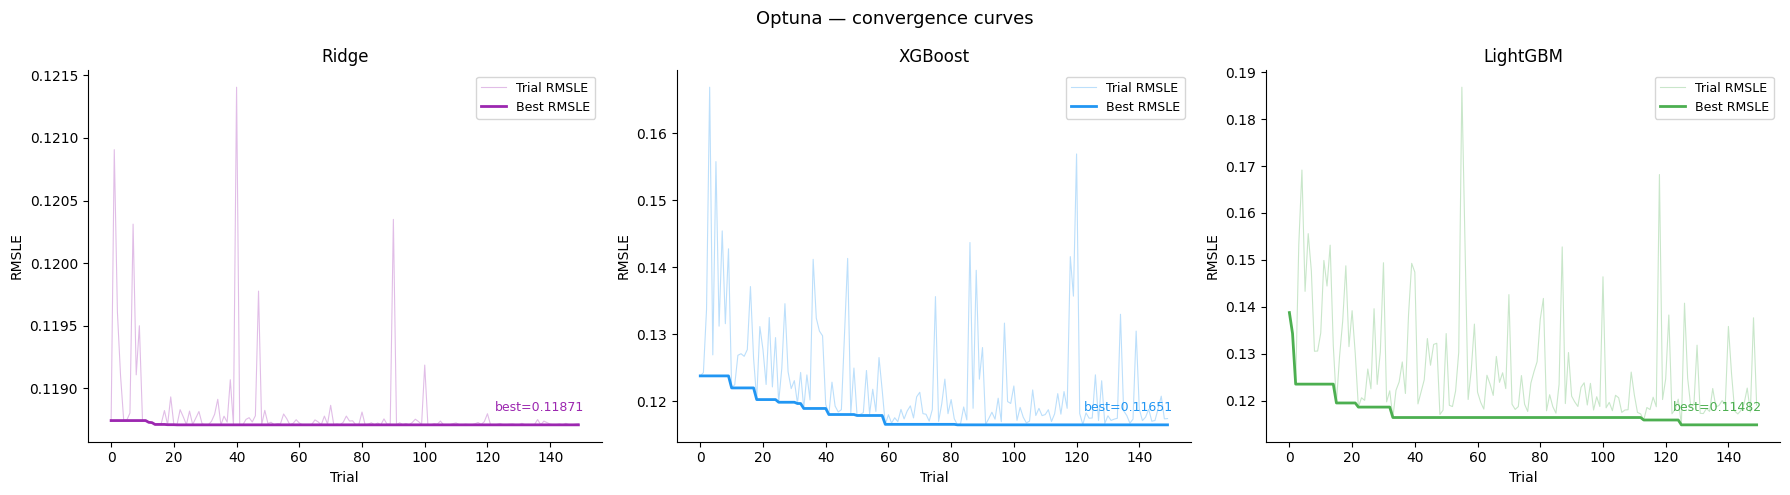

In [6]:
# Convergence curves — how the RMSLE improved over the course of the trials
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, study, name, color in zip(
    axes,
    [study_ridge, study_xgb, study_lgb],
    ['Ridge', 'XGBoost', 'LightGBM'],
    ['#9C27B0', '#2196F3', '#4CAF50']
):
    values = [t.value for t in study.trials if t.value is not None]
    best_so_far = pd.Series(values).cummin()

    ax.plot(values, alpha=0.3, color=color, linewidth=0.8, label='Trial RMSLE')
    ax.plot(best_so_far, color=color, linewidth=2.0, label='Best RMSLE')
    ax.set_title(f'{name}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('RMSLE')
    ax.legend(fontsize=9)
    ax.annotate(
        f'best={study.best_value:.5f}',
        xy=(len(values)-1, best_so_far.iloc[-1]),
        xytext=(-60, 10), textcoords='offset points',
        fontsize=9, color=color
    )

plt.suptitle('Optuna — convergence curves', fontsize=13)
plt.tight_layout()
plt.show()

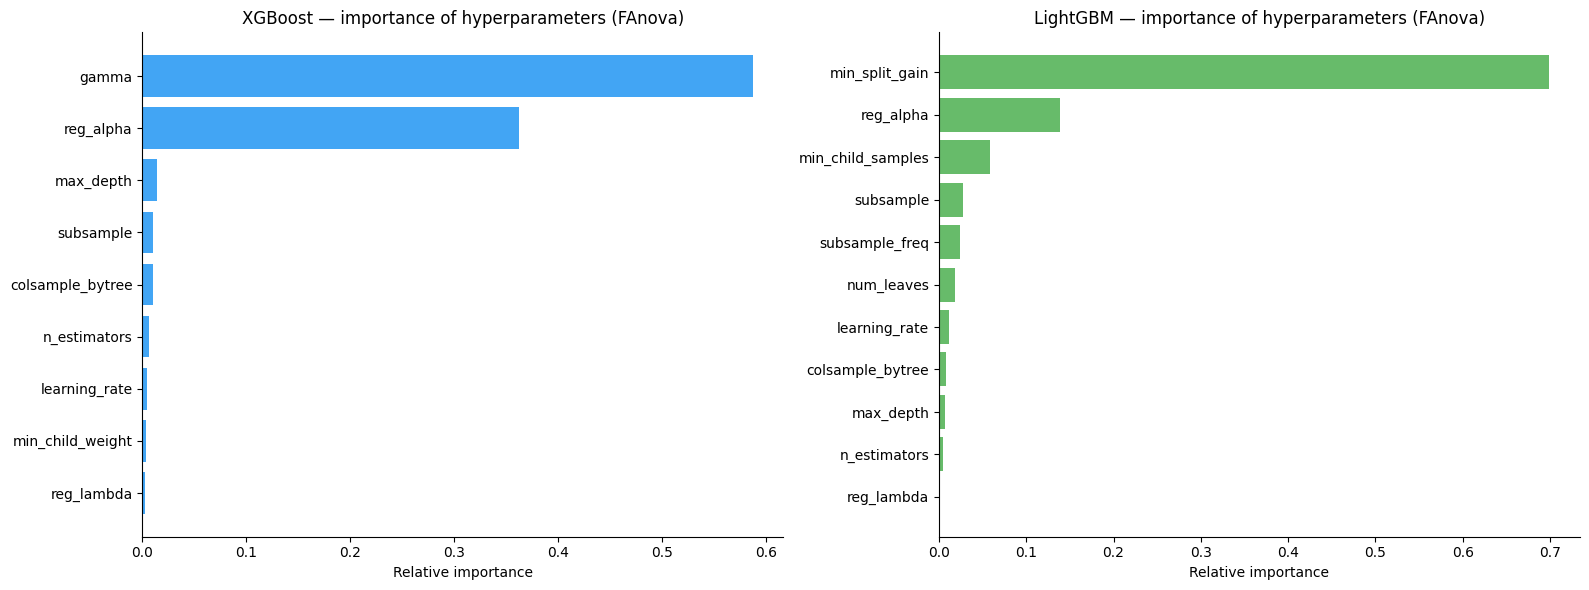

In [7]:
# importance of hyperparameters (Optuna FAnova)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, study, name, color in zip(
    axes,
    [study_xgb, study_lgb],
    ['XGBoost', 'LightGBM'],
    ['#2196F3', '#4CAF50']
):
    importance = optuna.importance.get_param_importances(study)
    params = list(importance.keys())
    vals   = list(importance.values())

    sorted_pairs = sorted(zip(vals, params))
    vals_s, params_s = zip(*sorted_pairs)

    ax.barh(params_s, vals_s, color=color, alpha=0.85)
    ax.set_title(f'{name} — importance of hyperparameters (FAnova)')
    ax.set_xlabel('Relative importance')

plt.tight_layout()
plt.show()

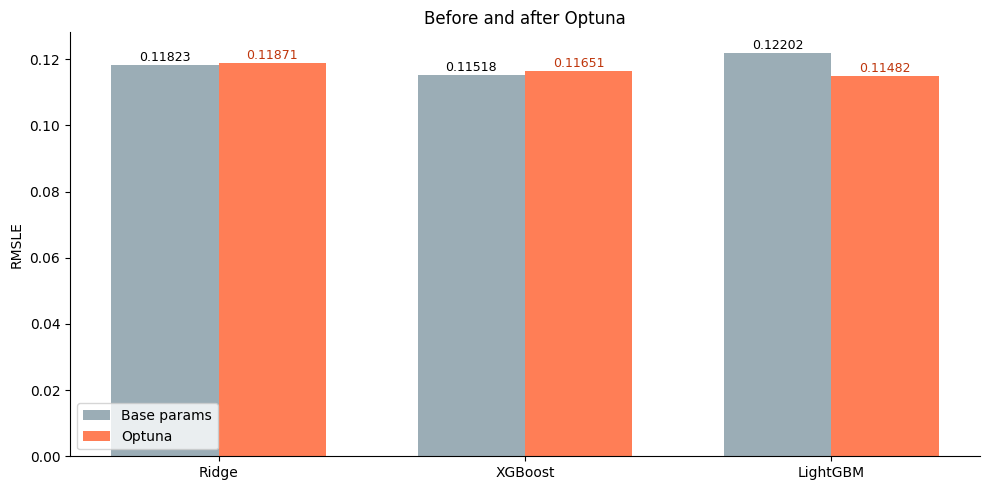


Upgrade:
  Ridge       : --0.00048  (-0.40%)
  XGBoost     : --0.00133  (-1.15%)
  LightGBM    : -0.00720  (5.90%)


In [8]:
# Comparison: Base Settings vs. Optimized Settings
baseline = {
    'Ridge':     0.11823,   
    'XGBoost':   0.11518,
    'LightGBM':  0.12202,
}
optimized = {
    'Ridge':    study_ridge.best_value,
    'XGBoost':  study_xgb.best_value,
    'LightGBM': study_lgb.best_value,
}

x = np.arange(3)
w = 0.35
names = list(baseline.keys())

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, [baseline[n] for n in names],  w, label='Base params', color='#90A4AE', alpha=0.9)
bars2 = ax.bar(x + w/2, [optimized[n] for n in names], w, label='Optuna',            color='#FF7043', alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{bar.get_height():.5f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{bar.get_height():.5f}', ha='center', va='bottom', fontsize=9, color='#BF360C')

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('RMSLE')
ax.set_title('Before and after Optuna')
ax.legend()
plt.tight_layout()
plt.show()

print('\nUpgrade:')
for name in names:
    delta = baseline[name] - optimized[name]
    pct   = delta / baseline[name] * 100
    print(f'  {name:12s}: -{delta:.5f}  ({pct:.2f}%)')

In [9]:
os.makedirs('models', exist_ok=True)

best_params = {
    'ridge':   best_ridge,
    'xgb':     {**best_xgb, 'n_jobs': -1, 'random_state': SEED, 'verbosity': 0},
    'lgb':     {**best_lgb, 'n_jobs': -1, 'random_state': SEED, 'verbose': -1},
    'scores': {
        'ridge_rmsle': study_ridge.best_value,
        'xgb_rmsle':   study_xgb.best_value,
        'lgb_rmsle':   study_lgb.best_value,
    }
}

# Сохраняем как JSON для читаемости
with open('models/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

# И как pkl для удобной загрузки
joblib.dump(best_params, 'models/best_params.pkl')

print('Best params saved')
print('   models/best_params.json')
print('   models/best_params.pkl')
print()
print(json.dumps(best_params, indent=2))

Best params saved
   models/best_params.json
   models/best_params.pkl

{
  "ridge": {
    "alpha": 0.6676653636204392
  },
  "xgb": {
    "n_estimators": 900,
    "learning_rate": 0.012955155367219017,
    "max_depth": 8,
    "min_child_weight": 8,
    "subsample": 0.5048184246025215,
    "colsample_bytree": 0.317820891454366,
    "gamma": 0.025186509507539877,
    "reg_alpha": 0.03492136835905574,
    "reg_lambda": 0.024507320972187375,
    "n_jobs": -1,
    "random_state": 42,
    "verbosity": 0
  },
  "lgb": {
    "n_estimators": 1600,
    "learning_rate": 0.013533860371835326,
    "num_leaves": 77,
    "max_depth": 5,
    "min_child_samples": 5,
    "subsample": 0.5664989187036742,
    "subsample_freq": 6,
    "colsample_bytree": 0.3162497595641107,
    "reg_alpha": 4.0653805863568905e-08,
    "reg_lambda": 1.9103778999426697e-06,
    "min_split_gain": 0.022454363120801794,
    "n_jobs": -1,
    "random_state": 42,
    "verbose": -1
  },
  "scores": {
    "ridge_rmsle": 0.11870655

In [10]:
X_test = pd.read_csv('data/processed/X_test.csv')
test_id = pd.read_csv('data/test.csv')['Id']

# Final models with the identified parameters
final_ridge = make_pipeline(
    RobustScaler(),
    Ridge(**best_ridge, random_state=SEED)
)
final_xgb = xgb.XGBRegressor(**best_params['xgb'])
final_lgb = lgb.LGBMRegressor(**best_params['lgb'])

print('Train the final models on the full dataset train...')
final_ridge.fit(X_train, y_train)
final_xgb.fit(X_train, y_train)
final_lgb.fit(X_train, y_train)
print('Ready')

Train the final models on the full dataset train...
Ready


In [11]:
# OOF 
def get_oof(model, X, y, cv):
    oof = np.zeros(len(y))
    for tr_idx, val_idx in cv.split(X):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof[val_idx] = model.predict(X.iloc[val_idx])
    return oof


oof_ridge = get_oof(final_ridge, X_train, y_train, kf)
oof_xgb   = get_oof(final_xgb,   X_train, y_train, kf)
oof_lgb   = get_oof(final_lgb,   X_train, y_train, kf)
print('OOF ready')

OOF ready


In [12]:
# Selecting blending weights
best_rmsle = np.inf
best_w     = None

for w_xgb in np.arange(0.0, 1.05, 0.05):
    for w_lgb in np.arange(0.0, 1.05 - w_xgb, 0.05):
        w_r = round(1.0 - w_xgb - w_lgb, 10)
        if w_r < 0:
            continue
        blend = w_xgb * oof_xgb + w_lgb * oof_lgb + w_r * oof_ridge
        rmsle  = np.sqrt(mean_squared_error(y_train, blend))
        if rmsle < best_rmsle:
            best_rmsle = rmsle
            best_w     = (round(w_xgb, 2), round(w_lgb, 2), round(w_r, 2))

w_xgb, w_lgb, w_ridge = best_w
print(f'Best weights: XGBoost={w_xgb}, LightGBM={w_lgb}, Ridge={w_ridge}')
print(f'OOF RMSLE blending: {best_rmsle:.5f}')

Best weights: XGBoost=0.0, LightGBM=0.6, Ridge=0.4
OOF RMSLE blending: 0.11234


In [13]:
# Final preds
pred_ridge = final_ridge.predict(X_test)
pred_xgb   = final_xgb.predict(X_test)
pred_lgb   = final_lgb.predict(X_test)

pred_blend = w_xgb * pred_xgb + w_lgb * pred_lgb + w_ridge * pred_ridge
pred_final = np.expm1(pred_blend)

# model saving
final_ridge.fit(X_train, y_train)
final_xgb.fit(X_train, y_train)
final_lgb.fit(X_train, y_train)

joblib.dump(final_ridge, 'models/ridge.pkl')
joblib.dump(final_xgb,   'models/xgb_model.pkl')
joblib.dump(final_lgb,   'models/lgb_model.pkl')

blend_config = {'w_xgb': w_xgb, 'w_lgb': w_lgb, 'w_ridge': w_ridge, 'cv_rmsle': best_rmsle}
joblib.dump(blend_config, 'models/blend_config.pkl')

# Submission
os.makedirs('submissions', exist_ok=True)
submission = pd.DataFrame({'Id': test_id, 'SalePrice': pred_final})
submission.to_csv('submissions/submission_optuna.csv', index=False)

print('All saved')
print(f'   models/ridge.pkl')
print(f'   models/xgb_model.pkl')
print(f'   models/lgb_model.pkl')
print(f'   models/blend_config.pkl')
print(f'   submissions/submission_optuna.csv')
print(f'\n   Final OOF RMSLE: {best_rmsle:.5f}')

All saved
   models/ridge.pkl
   models/xgb_model.pkl
   models/lgb_model.pkl
   models/blend_config.pkl
   submissions/submission_optuna.csv

   Final OOF RMSLE: 0.11234


In [14]:
print('=' * 60)
print('SUMMARY OPTUNA TUNING')
print('=' * 60)
print(f'''
   Best RMSLE after optimization:
   Ridge    = {study_ridge.best_value:.5f}
   XGBoost  = {study_xgb.best_value:.5f}
   LightGBM = {study_lgb.best_value:.5f}
   Blend    = {best_rmsle:.5f}

   Blending weights:
   XGBoost  = {w_xgb}
   LightGBM = {w_lgb}
   Ridge    = {w_ridge}

   Tips for improvement:
   - Increase N_TRIALS to 200–300
   - Use N_FOLDS=10 for accurate evaluation
   - Add CatBoost as the third boosting model
   - Try Stacking instead of simple blending

→ Next step: app.py (Streamlit)
''')

SUMMARY OPTUNA TUNING

   Best RMSLE after optimization:
   Ridge    = 0.11871
   XGBoost  = 0.11651
   LightGBM = 0.11482
   Blend    = 0.11234

   Blending weights:
   XGBoost  = 0.0
   LightGBM = 0.6
   Ridge    = 0.4

   Tips for improvement:
   - Increase N_TRIALS to 200–300
   - Use N_FOLDS=10 for accurate evaluation
   - Add CatBoost as the third boosting model
   - Try Stacking instead of simple blending

→ Next step: app.py (Streamlit)

